In [2]:
import warnings
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Iterable
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
%matplotlib inline

warnings.filterwarnings('ignore')

DATA_PATH = './data_numpy'
BEST_PARAM_PATH = './best_params/oversampling/LR'

# Oversampled version
Xtr = pd.read_csv(f'{DATA_PATH}/Xtr_resampled_encoded.csv')
Xval = pd.read_csv(f'{DATA_PATH}/Xval_resampled_encoded.csv')
Xte = pd.read_csv(f'{DATA_PATH}/Xte_resampled_encoded.csv')
ytr = pd.read_csv(f'{DATA_PATH}/ytr_resampled_encoded.csv')
yval = pd.read_csv(f'{DATA_PATH}/yval_resampled_encoded.csv')
yte = pd.read_csv(f'{DATA_PATH}/yte_resampled_encoded.csv')

In [3]:
pos = np.sum(ytr == 1)
neg = np.sum(ytr == 0)
pr = float(pos / (pos + neg))  # positive rate
nr = 1 - pr  # negative rate
print(f"fraud rate: {pr} ~ {pr:.3%}\nnon-fraud rate: {nr} ~ {nr:.3%}")

fraud rate: 0.477042379728472 ~ 47.704%
non-fraud rate: 0.522957620271528 ~ 52.296%


In [4]:
lams = np.linspace(1, 100, 20)


def CV(
        Xtr: pd.DataFrame, ytr: pd.Series,
        Xval: pd.DataFrame, yval: pd.Series,
        lams: Iterable,
):
    best_score = -1
    best_lam = None
    i = 1

    fits = len(lams)

    for lam in lams:
        timer = time.time()

        model = LogisticRegression(C=lam, n_jobs=-1)
        model.fit(Xtr, ytr)

        # probabilities for class 1
        y_pred = model.predict_proba(Xval)[:, 1]
        score = metrics.roc_auc_score(yval, y_pred)

        end = time.time() - timer
        elapsed_time = f"{end:.1f}s" if end < 60 else f"{(end / 60):.1f}min"
        print(
            f"[fit {i}/{fits}] END {lam=}, score={score:.6f} total time=   {elapsed_time}")
        i += 1

        if score > best_score:
            best_score = score
            best_lam = lam

    print(f"Best lam: {best_lam}")
    print(f"Best roc_auc score: {best_score}")

    return best_lam, best_score

In [5]:
choice = input("Do you want to execute this cell? (yes/no): ")

if choice.lower() == "yes":
    print("Executing cross validation...")
    best_lam, _ = CV(Xtr, ytr, Xval, yval, lams)
    np.save(f'{BEST_PARAM_PATH}/best_lam.npy', best_lam)
else:
    print("Loading data locally...")
    best_lam = np.load(f'{BEST_PARAM_PATH}/best_lam.npy')

print("Best lambda:", best_lam)

Loading data locally...
Best lambda: 448.0


In [7]:
model = LogisticRegression(C=float(best_lam), n_jobs=-1)
model.fit(Xtr, ytr)

LogisticRegression(C=448.0, n_jobs=-1)

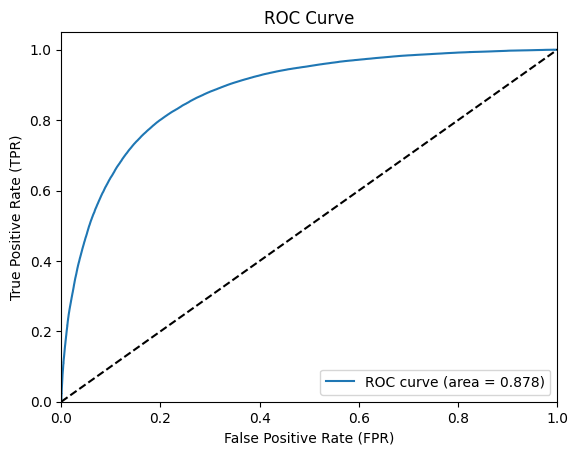

In [8]:
y_pred = model.predict_proba(Xte)[:, 1]  # probabilities for class 1
fpr, tpr, _ = metrics.roc_curve(yte, y_pred)
roc_auc = metrics.auc(fpr, tpr)

# ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')  # bisector
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [9]:
y_pred_f1 = model.predict(Xte)

f1 = metrics.f1_score(yte, y_pred_f1, average=None)
precision = metrics.precision_score(yte, y_pred_f1, average=None)
recall = metrics.recall_score(yte, y_pred_f1, average=None)
# overall precision
precision_avg = metrics.precision_score(yte, y_pred_f1, average='weighted')
recall_avg = metrics.recall_score(yte, y_pred_f1, average='weighted')
f1_avg = metrics.f1_score(yte, y_pred_f1, average='weighted')
acc = metrics.accuracy_score(yte, y_pred_f1)

print(f'''
Class wise metrics:
{f1=}
{precision=}
{recall=}

Overall metrics
{f1_avg=}
{precision_avg=}
{recall_avg=}
''')


Class wise metrics:
f1=array([0.76327217, 0.73609011])
precision=array([0.66029541, 0.89100251])
recall=array([0.90430331, 0.62706644])

Overall metrics
f1_avg=0.7481843822065489
precision_avg=0.7883526508616265
recall_avg=0.7504190617014238



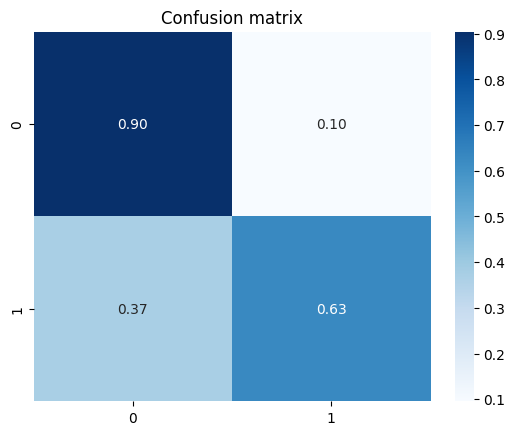

In [10]:
import seaborn as sns

cm = metrics.confusion_matrix(yte, y_pred_f1)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.title("Confusion matrix")
sns.heatmap(cm_norm, annot=True, fmt=".5f", cmap="Blues")
plt.show()